In [1]:
#Asked Chat GPT to help me detect a device for training a PyTorch model
import torch

# Choose the best available device for training in this order:
# 1) Apple Silicon GPU via MPS (macOS M1/M2/M3)
# 2) NVIDIA GPU via CUDA
# 3) CPU fallback
if torch.backends.mps.is_available():
    device = torch.device("mps")
    device_name = "Apple Silicon GPU (MPS)"
elif torch.cuda.is_available():
    device = torch.device("cuda")
    device_name = f"NVIDIA GPU ({torch.cuda.get_device_name(0)})"
else:
    device = torch.device("cpu")
    device_name = "CPU"

# Use this `device` variable for model and tensor placement during training. 
print(f"Training device selected: {device_name}")
print(f"torch.device: {device}")

Training device selected: Apple Silicon GPU (MPS)
torch.device: mps


# Transformer Transfer Learning Introduction

For this lab, "Transfer Learning and Transformers", I have chosen to perform a classification task where my models will be predicting 4 different classes on the sequential dataset "ag_news" that can be accessed simply from installing the package below:

```bash
pip install datasets
```

and then accessing the dataset via this import:

```bash
from datasets import load_dataset
```

## What is in the "ag_news" dataset and why are we using it?

#### First I load in the dataset to take a peek

In [ ]:
#Loading the dataset and printing the first 10 rows in a nice format

import pandas as pd
from IPython.display import display, Markdown
from datasets import load_dataset

# Load the AG News dataset
dataset = load_dataset("ag_news")
train_dataset = dataset["train"]
test_dataset = dataset["test"]

# Build a concise dataset overview
label_feature = train_dataset.features["label"]
label_names = label_feature.names if hasattr(label_feature, "names") else []

overview_lines = [
    "## AG News Dataset Overview",
    f"- Training rows: {len(train_dataset):,}",
    f"- Test rows: {len(test_dataset):,}",
    f"- Columns: {', '.join(train_dataset.column_names)}",
]

if label_names:
    overview_lines.append(f"- Labels: {', '.join(label_names)}")

display(Markdown("\n".join(overview_lines)))

# Show the first 10 training rows cleanly in a dataframe
first_10_df = pd.DataFrame(train_dataset[:10])

if label_names:
    first_10_df["label_name"] = first_10_df["label"].map(lambda value: label_names[value])
    first_10_df = first_10_df[["text", "label", "label_name"]]

display(Markdown("### First 10 Training Rows"))
display(first_10_df)

## AG News Dataset Overview
- Training rows: 120,000
- Test rows: 7,600
- Columns: text, label
- Labels: World, Sports, Business, Sci/Tech

### First 10 Training Rows

,text,label,label_name
0,Wall St. Bears Claw Back Into the Black (Reute...,2,Business
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2,Business
3,Iraq Halts Oil Exports from Main Southern Pipe...,2,Business
4,"Oil prices soar to all-time record, posing new...",2,Business
5,"Stocks End Up, But Near Year Lows (Reuters) Re...",2,Business
6,Money Funds Fell in Latest Week (AP) AP - Asse...,2,Business
7,Fed minutes show dissent over inflation (USATO...,2,Business
8,Safety Net (Forbes.com) Forbes.com - After ear...,2,Business
9,Wall St. Bears Claw Back Into the Black NEW Y...,2,Business


### Dataset Questions


##### First Question: What is in this dataset? 

"ag_news" consists of rows that are real world news article headlines from over 2,000 news sources with a short description after each title (all in the same string). Each of these rows consists of the following format

- `text title`: headline and description of the article
- the `label`: a number 0-3 that signifys 4 different classes:
    - 0 = World
    - 1 = Sports
    - 2 = Business
    - 3 = Sci/Tech

Amount of training rows = 120k

"World, Sports, Business, Sci/Tech" labes are all split evenly 25% throughout the train and test datasets

Train dataset = 120k rows
Test dataset = 7.6k rows

##### Second Question: Why am I choosing this dataset?

On my current hardware I am using (Macbook M1 Pro chip during spring break), I believe I wouldn't be able to train a more complex foundational model feasibly that would allow me to explore other unique and interesting tasks that models like BERT wouldn't be able to perform as well at. Although with hardware limitation, I didn't want to make it as simple as a binary sentiment classifier on text either which is why I believe I found a happy medium. This dataset "ag_news" has 4 different classes of worldly categories which will make my project a little more interest than sentiment, although still very feasible to predict. 

This dataset it also very easy to access and already cleanly split into evenly sampled train and test datasets. 

##### What I would have done on my main setup hardware (Nvidia 4070 gpu)

Instead of being stuck to an option like BERT for a foundational model, with a more computationally strong option like a 4070, I would be able to choose between more robust and higher performing models like roberta and deberta. This would allow me to try a more interesting task like classifying fake vs real news to see the difference between a baseline model and transfer learned pre-trained transformer model. Although I digress.

This is where I will continue into the pipeline I will be using to complete this project

##### What models will I use to complete this project

Baseline Model:
- TF-IDF -> Random Forest
- DistilBERT (of which will be fined tuned as well)

I will continue to expand on these in the next section of this project



# Transformer Transfer Learning Project Overview

<u>Questions I will be answering in this section:</u>
- What is the classification task? What business or policy case does it solve? Is this multi-task? Explain.
- What is the feature data? How is it stored? Who collected the data? Why? When? Is the data multi-modal?
- What evaluation criteria will you be using and why? Why does this support the business or policy case?


### What is the classification task? What business or policy case does it solve? Is this multi-task? Explain.

Based off the dataset that I had described in the introduction, my models (random forest and DistilBERT) will be classifying titles and descriptions of articles (all in one string together) in the following topics:
- World
- Sports
- Business
- Sci/Tech

**This is a multi-class text classification task** of which the goal will be to train the models on text to auto classify them into one of the 4 categories above. 

This, therefore, will be a **Many-To-One Sequential Classification Task**. Each row has text that is in sequential structure that is used to classify a certain topic and therefore a single output label. Therefore this will be a good tasks for the transformer model as they are designed to process sequential data and learn contextual relationships between words.

This task will **not be multi-task** due to how I am only solving a single objective


<u>Business perspective??</u>

In many info systems and content management platforms, people constantly are intaking large amounts of new articles in consist periods. Therefore, being able to retrieve certain articles or information at ease becomes a harder and harder problem as time goes on. Some techniques that industries are using to categorize data currently include through News organizations (retrive themselves), search engines, and financial analytics platforms. Although, potentially this tool could help them find their desired content easier. 

Real-world application of this project could be:
- organizing articles in news aggregation platforms
- automatically tagging articles in content management systems (can create better reccomendation engines)
- filtering financial or technology-related news for analysts
- and more



### What is the feature data? How is it stored? Who collected the data? Why? When? Is the data multi-modal?

<u>Background on the "ag_news" dataset</u>:

This dataset being used in this project is from the "AG News Topic Classification dataset". At its origin, this dataset's contents were collected from over 2,000 news sources. The dataset was introduced by **Xiang Zhang**, **Xiangyu Wang**, and **Yann LeCun** in 2015 for studying text classification methods in deep learning.


For specifics of what the dataset contains click this link [here](#dataset-questions)

(you can also scroll manually above to the "What is in this dataset?" section)

For how I am loading and previewing the dataset in this notebook, click [here](#First-we-load-in-our-dataset-to-take-a-peek).


<u>More info for storage and loading the dataset</u>

In this project, the data is loaded through the Hugging Face `datasets` library as a `DatasetDict` with two splits: `train` and `test`.

Again, each row contains a text field and an integer label (0-3). Therefore, the data is **not multi-modal**. It is text-only, so both models operate on the same text input with different representations.

For the baseline model, the text is converted into numerical feature vectors using TF-IDF vectorization.

For the transformer-based model, the text is tokenized into subword tokens using the DistilBERT tokenizer so the model can learn the contextual embeddings.

### What evaluation criteria will I be using and why? Why does this support the business or policy case?

Metrics I will use to evaluate my models' performance:
- Classification Accuracy
- Precision
- Recall
- F1 Score

Although the primary metric I will be using will be:
**Classification Accuracy**


<u>Why?</u>
This metric will measure the correctly predicted labels that is made by the models. Therefore this directly contributed to the task as hand of putting the titles (or other businesses cases "articles") into the correct bin for easier recall and organization. Also since the dataset has all 4 class accounted for equally, the accuracy will be a good metric to use for determining desired performance. 

If classes were not accounted for equally, grabbing the precision, recall, and ultimately the F1 score would be the prioritized metric. Although I will still use these metrics for clarity. 

I also aim to captures these metrics (classification accuracy, precision, recall, F1 Score) for each individual class per model. Therefore I can see if there is any data that is particularly difficult to classify. The format will look something like below:
- Baseline Model
    - World = accuracy, percision, recall, f1
    - Sports = accuracy, percision, recall, f1
    - Business = accuracy, percision, recall, f1
    - Sci/Tech = accuracy, percision, recall, f1
- Transfer Learned Pre-Trained Transformer Model
    - World = accuracy, percision, recall, f1
    - Sports = accuracy, percision, recall, f1
    - Business = accuracy, percision, recall, f1
    - Sci/Tech = accuracy, percision, recall, f1
- Fine Tuned Model
    - World = accuracy, percision, recall, f1
    - Sports = accuracy, percision, recall, f1
    - Business = accuracy, percision, recall, f1
    - Sci/Tech = accuracy, percision, recall, f1

Finally, the goal of this evluation is to compare these 3 modeling strategies:
- A baseline model (random forest) trained from scratch using traditional machine learning methods (TF-IDF)
- A transfer learning model using a pre-trained transformer (DistilBERT) with frozen encoder weights
- A fine-tuned transformer model where some or all of the transformer layers are trained on the dataset

By comparing each of these, this project will be able to demonstrate the improvements on classification tasks like these (can't know for sure without testing more tasks) by transfer learning a pre-trained transformer. 

In the business perspective, evaluating performance on this task can help determine how accurate the models will be able putting certain "articles" into their respective bins. Therefore this can determine how useful and valuable creating models likes these for companies would be. 

# My Chosen Foundational Model: DistilBERT

<u>Questions to be answered:</u> 
- What is the model? 
- What task(s) was this foundational model trained upon? 
- Explain if the new task is within the same domain, across domains, etc.  
- Include specifics about the architecture used in the foundational model, storage, computation, etc.

### What is DistilBERT

before talking about DistilBERT, we have to understand BERT. 

##### First what is BERT? 
- BERT is a large transformer language model that was trained by Google to understand language context.

Therefore we can think of BERT as a specialize Transformer which is specifically designed to understand text, but not exactly generate it. I currently understand BERT as a smaller encoder-only version which is a predecessor of LLM like like Chat GPT. Although that is where models like BERT and GPT differ. BERT is encoder only for understanding text and GPT is decoder only for generating text. 

##### Next what is DistilBERT?
- it is just a watered down version of regular BERT, let me explain.

DistilBERT was created by Hugging Face researchers to mimic tasks/performance of BERT while making the whole model:
- smaller
- faster
- and less memory intensive

And yes it did keep most of its performance (relative to BERT). 

##### The real differences between the two:

| Model      | Parameters   |
| ---------- | ------------ |
| BERT-base  | ~110 million |
| DistilBERT | ~66 million  |

These parameter difference exist while DistilBERT retains ~95% of BERT performance while being about 40% smaller and ~60% faster.


##### Why am I choosing a watered down version of BERT in DistilBERT? 

- *cough *cough my hardware *cough
- And because why not



### What task(s) is DistilBERT pretrained on?

Since DistilBERT inherits most of BERTs pretrained objective, the main task of the model was **Mask Language Modeling (MLM)**

##### What is MLM?

during traing, the model is given sentences of which there are words missing like below:

- The stock market crashed after the [MASK] report.

And its task is to try to predict those words. It could predict something along the lines of: 
- Fiscal
- Economic
- Inflation

This forces DistilBERT to learn general language through:
- grammar
- context
- word relationships
- and semantic meaning


### Is our new task (article classification) in the same domain as DistilBERTs original task?

DistilBERT was trained on the data of the large general language collection. This includes from places like:
- Wikipedia
- BooksCorpus

which underlying, did contain a lot of articles about science, technology, and all of our categories alike. Therefore since our model was pretrained on the basis of large language understanding, we are atadpting it into the same domain of the task large language classification. 


We aren't transfering over to another mode like from text --> images (which would be  outside the domain). Therefore since we are staying inside the same domain, I believe that when I employ my methods of transfer learning (and fine tuning) that we will get a very effective result because DistilBERT already understands grammar, word relationships, and contextual meaning.

### DistilBERT Architecture

DistilBERT's architecture consist of 

- 6 transformer layers (compared to 12 layers in regular BERT)

    In each transformer layer contains:
    - Self-attention mechanism
    - Feed Forward Neural Network
    - Residual Connections
    - Layer Normalization

- 12 Attention heads (for different types of linguistic relationships)
- 768 dimensions per token in embedding matrix
- Parameters = ~66 million

##### DistilBERT Storage and Computation

Since this model consists of half of the parameters (and layers) as BERT, the disk storage will also be reduced significantly as below

| Model      | Disk Storage   |
| ---------- | ------------ |
| BERT-base  | ~420 MB |
| DistilBERT | ~250 MB  |

Note: This also means that DistilBERT's computation speed is ~60% faster than BERT's


<u>Although there are parts of the DistilBERT that doesn't change from BERT including:</u>

- Hidden Dimension Layer

DistilBERT keeps the 768 dimension embedding layer and 12 attention heads

- Tokenization and input length

keeps the ~30,522 tokens vocabulary size, 512 tokens max input length. Although for the sake of our projet we will be using 128-256 token due to the sizes of entries in our sequential data. 

Finally, during training or fine-tuning, the main memory usage will come from:
- model parameters
- intermediate activations
- gradients

But because DistilBERT has fewer layers, it will require:
- fewer stored activations
- fewer gradient computations
- ess GPU/accelerator memory

Which therefore will make it a lot more practical for fine-tuning on my current hardware (Apple Silicon GPUs) while working in PyTorch's MPS backend. 












# Defining the split in my data and the loss function

### Data Spliting Strategies 

First off, I didn't have to create a strategy to split the data as it was already split into training and testing sections via the load_dataset function from datasets. Below is the number of samples in each:

| Dataset Split | Number of Samples |
| ------------- | ----------------- |
| Training set  | 120,000           |
| Testing set   | 7,600             |

I've also outlined this in my dataset questions section [here](#dataset-questions)

You can also find what the dataset looks like [here](#first-i-load-in-the-dataset-to-take-a-peek)


Therefore the split between train and test is ~94% and ~6% respectively. Could this be concerning?
- No, because the sampling of 7600 for testing is already sufficiently large and will provide reliable evaluation metrics. Also allowing the training dataset to be larger is beneficialy for transformer models to learn cpomlex language pattern, which could be beneficial in the sequential title/description features. 

### Stratification 

The AG News dataset it split into 4 categories as I have outline prior:

- World
- Sports
- Busines
- Sci/Tech

Each of these maintain a 25% part of the entire dataset (equal in training and testing individually too). Therefore we can considered this dataset stratified because all classes are equal amongst data (train and testing included).

### Loss Functions

##### Foundational Model (DistilBERT)

For this project, although very simple, I will be using the **Cross Entropy Loss** function, as it is the standard for mulit-class classification tasks. During training, the DistilBERT transformer model outputs logits (numbers before softmax usually) which will then be passed through our Cross Entropy Loss function to compare the true label of the sample with the predicted answer. Then as normal the Cross Entropy function penalizes for wrong answers and then will back propogate through our system to increase prediction scores. Although in this case with our pretrained transformer model, DistilBERT, we will only retrain a section before fine-tuning (of which we will unfreeze a lot more layers).

Also since we are only labeling our predicted data with a **single label**, we will then therefore only need to use one loss function (won't need multiple).

##### Baseline Model (Random Forest or RF)

The random forests don't optimize themselves direclty using a neural-network style loss function during training. Therefore, instead RF will use decision tree splitting criteria such as Gini impurity or entropy to decide how to split the data at each node of the tree. This will provide a similar purpose to a traditional loss function by guiding the model toward splits that improve classification accuracy.




# Training our baseline model

<u>Task at hand:</u>
 Train a baseline model from scratch to perform the classification task.   That is, do NOT use transfer learning for this step--you are training a model to see the baseline performance.   Verify the model converges (even if the model is overfit). Note: This should NOT mirror the foundational model. It does NOT even need to be a transformer--this model may be far less computational to train (perhaps a random forest or variant). 


In [ ]:
#Load in our dataset using the Hugging Face Datasets library
dataset = load_dataset("ag_news")
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

In [14]:
# Convert data to pandas dataframe for easier viewing and manipulation
from typing import cast

import pandas as pd
from IPython.display import Markdown, display

dataset_train = dataset["train"]
dataset_test = dataset["test"]

# Cast to DataFrame to avoid notebook type-checker false positives
train_df = cast(pd.DataFrame, dataset_train.to_pandas())
test_df = cast(pd.DataFrame, dataset_test.to_pandas())

display(Markdown("### First 10 Training Rows"))
display(train_df.head(10))

print(train_df.columns)


### First 10 Training Rows

,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2
3,Iraq Halts Oil Exports from Main Southern Pipe...,2
4,"Oil prices soar to all-time record, posing new...",2
5,"Stocks End Up, But Near Year Lows (Reuters) Re...",2
6,Money Funds Fell in Latest Week (AP) AP - Asse...,2
7,Fed minutes show dissent over inflation (USATO...,2
8,Safety Net (Forbes.com) Forbes.com - After ear...,2
9,Wall St. Bears Claw Back Into the Black NEW Y...,2


Index(['text', 'label'], dtype='str')


In [15]:
#split into training and test sets for feature and label extraction
X_train = train_df["text"]
y_train = train_df["label"]

X_test = test_df["text"]
y_test = test_df["label"]


In [ ]:
#inspect a few of the examples
label_names = ["World", "Sports", "Business", "Sci/Tech"]

for i in range(3):
    print(f"Example {i+1}")
    print("Label:", label_names[y_train.iloc[i]])
    print("Text:", X_train.iloc[i][:300])
    print("-" * 80)

Example 1
Label: Business
Text: Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.
--------------------------------------------------------------------------------
Example 2
Label: Business
Text: Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and occasionally\controversial plays in the defense industry, has quietly placed\its bets on another part of the market.
--------------------------------------------------------------------------------
Example 3
Label: Business
Text: Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\about the economy and the outlook for earnings are expected to\hang over the stock market next week during the depth of the\summer doldrums.
--------------------------------------------------------------------------------


In [17]:
#convert the text data into TF-IDF features using scikit-learn's TfidfVectorizer
#this specifically converts the text into a sparse matrix of TF-IDF features, which can be used as input to machine learning models.
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (120000, 20000)
Testing TF-IDF shape: (7600, 20000)


In [18]:
#train a simple machine learning model (e.g., Random Forest) on the TF-IDF features to establish a baseline performance before moving on to transformer-based models.
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_tfidf, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [19]:
#make predictions on the test set
y_pred = rf_model.predict(X_test_tfidf)

In [ ]:
#evaluate the baseline model's performance using accuracy, classification report
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
print(f"Baseline Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_names))

Baseline Accuracy: 0.8967

Classification Report:
              precision    recall  f1-score   support

       World       0.92      0.90      0.91      1900
      Sports       0.91      0.97      0.94      1900
    Business       0.87      0.85      0.86      1900
    Sci/Tech       0.88      0.87      0.87      1900

    accuracy                           0.90      7600
   macro avg       0.90      0.90      0.90      7600
weighted avg       0.90      0.90      0.90      7600



Matplotlib is building the font cache; this may take a moment.


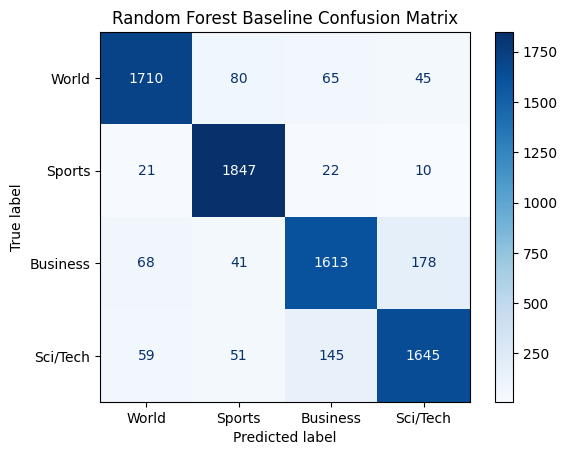

In [ ]:
#visualize the confusion matrix for the baseline model's predictions
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(cmap="Blues")
plt.title("Random Forest Baseline Confusion Matrix")
plt.show()